In [17]:
import pandas as pd

#List of files
files = [
    'Charging_station_A_Calif.csv',
    'Charging_station_B_Calif.csv',
    'Charging_station_C_Calif.csv'
]

#Creating a list to hold the dataframes
df_list =[]

for file in files:
    #Extracting station ID from filename (A, B, C)
    station_id = file.split('_')[2]

    #Reading the csv file
    df = pd.read_csv(file)

    #Add the station_ID column
    df['Station_ID'] = station_id

    #Appending the dataframe to the list
    df_list.append(df)


#Concatenating all dataframes in list to single dataframe
df_merged = pd.concat(df_list, ignore_index= True)

#Saving the final merged file
df_merged.to_csv('EV_Charging_California_Merged.csv', index=False)

print("Files successfully merged!")
print("Merged data preview: ")
print(df_merged.head())
print("\nMerged data info:")
df_merged.info()

Files successfully merged!
Merged data preview: 
       Date     Time  EV Charging Demand (kW)  Solar Energy Production (kW)  \
0  1/1/2021  0:00:00                 0.112362                      0.125388   
1  1/1/2021  1:00:00                 0.285214                      0.052697   
2  1/1/2021  2:00:00                 0.219598                      0.105035   
3  1/1/2021  3:00:00                 0.179598                      0.073839   
4  1/1/2021  4:00:00                 0.046806                      0.068614   

   Wind Energy Production (kW)  Electricity Price ($/kWh) Grid Availability  \
0                     0.009105                   0.137310         Available   
1                     0.107589                   0.125105         Available   
2                     0.043996                   0.106661         Available   
3                     0.275727                   0.072209         Available   
4                     0.059824                   0.091090         Available   

 

In [18]:
#Combining date and time to a single object "datetime"--> backbone to time-series analysis
#Ensuring "Date" and "Time" are strings, then combining them
#Adding 'format=mixed' to pd.to_datetime function to resolve error
df_merged['Timestamp'] = pd.to_datetime(df_merged['Date'].astype(str) + ' '+df_merged['Time'].astype(str),
                                       format = 'mixed'
                                       )

#Setting the new 'Timestamp' as the index
df_merged.set_index('Timestamp', inplace=True)

#Dropping the old columns
df_merged.drop(['Date', 'Time'], axis=1, inplace=True)
print("Successfully set 'Timestamp' as index and dropped old columns.")
print("\nData preview:")
print(df_merged.head())

Successfully set 'Timestamp' as index and dropped old columns.

Data preview:
                     EV Charging Demand (kW)  Solar Energy Production (kW)  \
Timestamp                                                                    
2021-01-01 00:00:00                 0.112362                      0.125388   
2021-01-01 01:00:00                 0.285214                      0.052697   
2021-01-01 02:00:00                 0.219598                      0.105035   
2021-01-01 03:00:00                 0.179598                      0.073839   
2021-01-01 04:00:00                 0.046806                      0.068614   

                     Wind Energy Production (kW)  Electricity Price ($/kWh)  \
Timestamp                                                                     
2021-01-01 00:00:00                     0.009105                   0.137310   
2021-01-01 01:00:00                     0.107589                   0.125105   
2021-01-01 02:00:00                     0.043996           

Generating plot for EV Charging Demand over time...


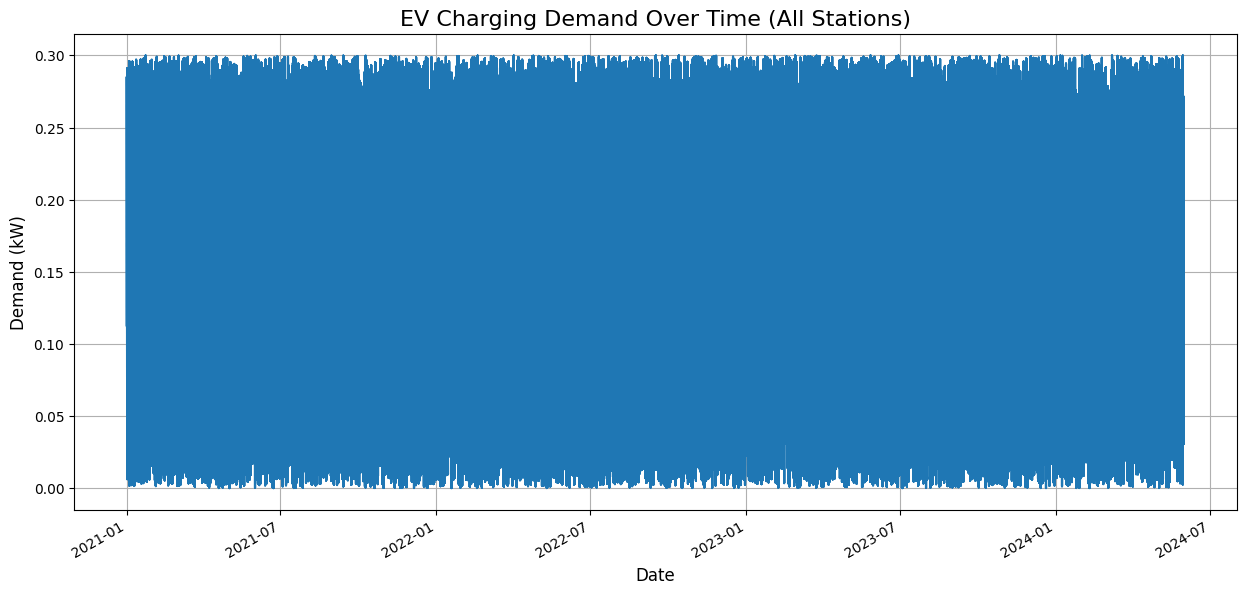

In [19]:
# --- VISUALIZE OVERALL DEMAND ---
print("Generating plot for EV Charging Demand over time...")
import matplotlib.pyplot as plt
#Set size of plot for better readability
plt.figure(figsize=(15,7))

#Plot the demand column against the index
df_merged['EV Charging Demand (kW)'].plot()

#Adding details to the plot
plt.title('EV Charging Demand Over Time (All Stations)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Demand (kW)', fontsize =12)
plt.grid(True) #adding grid for easier reading
plt.show()

Created 'hour' and 'day_of_week' columns.
Generating boxplot to check for weekly patterns...


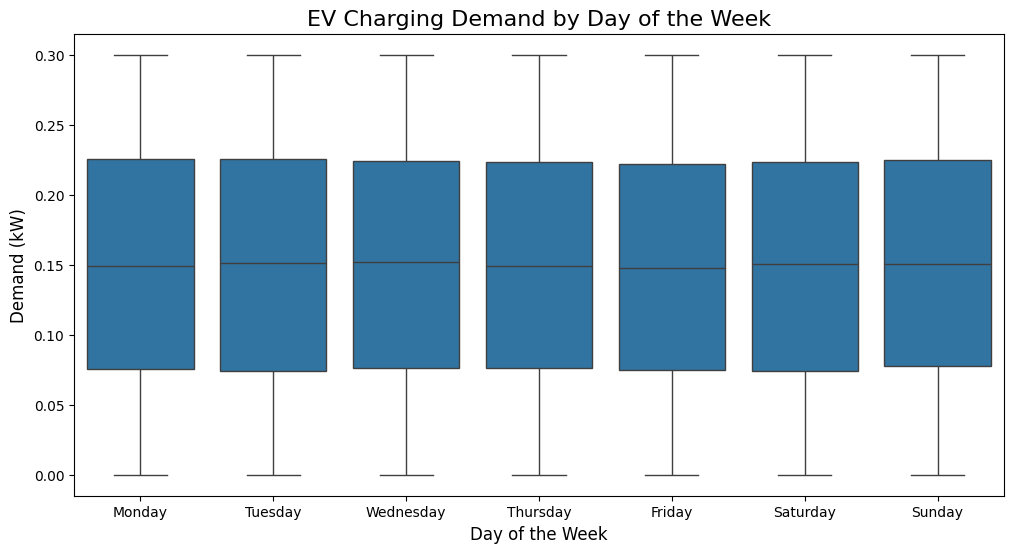

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- CHECK FOR WEEKLY SEASONALITY (Corrected) ---

# Create columns for analysis if they don't already exist
if 'hour' not in df_merged.columns:
    df_merged['hour'] = df_merged.index.hour
if 'day_of_week' not in df_merged.columns:
    df_merged['day_of_week'] = df_merged.index.day_name()

print("Created 'hour' and 'day_of_week' columns.")
print("Generating boxplot to check for weekly patterns...")

# Define the order of days for the plot
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# THE FIX: Reset the index to create a clean, unique index for plotting
# We pass this new 'plot_data' DataFrame to seaborn
plot_data = df_merged.reset_index()

# Create the boxplot using the new DataFrame
plt.figure(figsize=(12, 6))
sns.boxplot(x='day_of_week', y='EV Charging Demand (kW)', data=plot_data, order=day_order)

# Add details to the plot
plt.title('EV Charging Demand by Day of the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Demand (kW)', fontsize=12)

# Display the plot
plt.show()

Generating plots to check for hourly patterns...


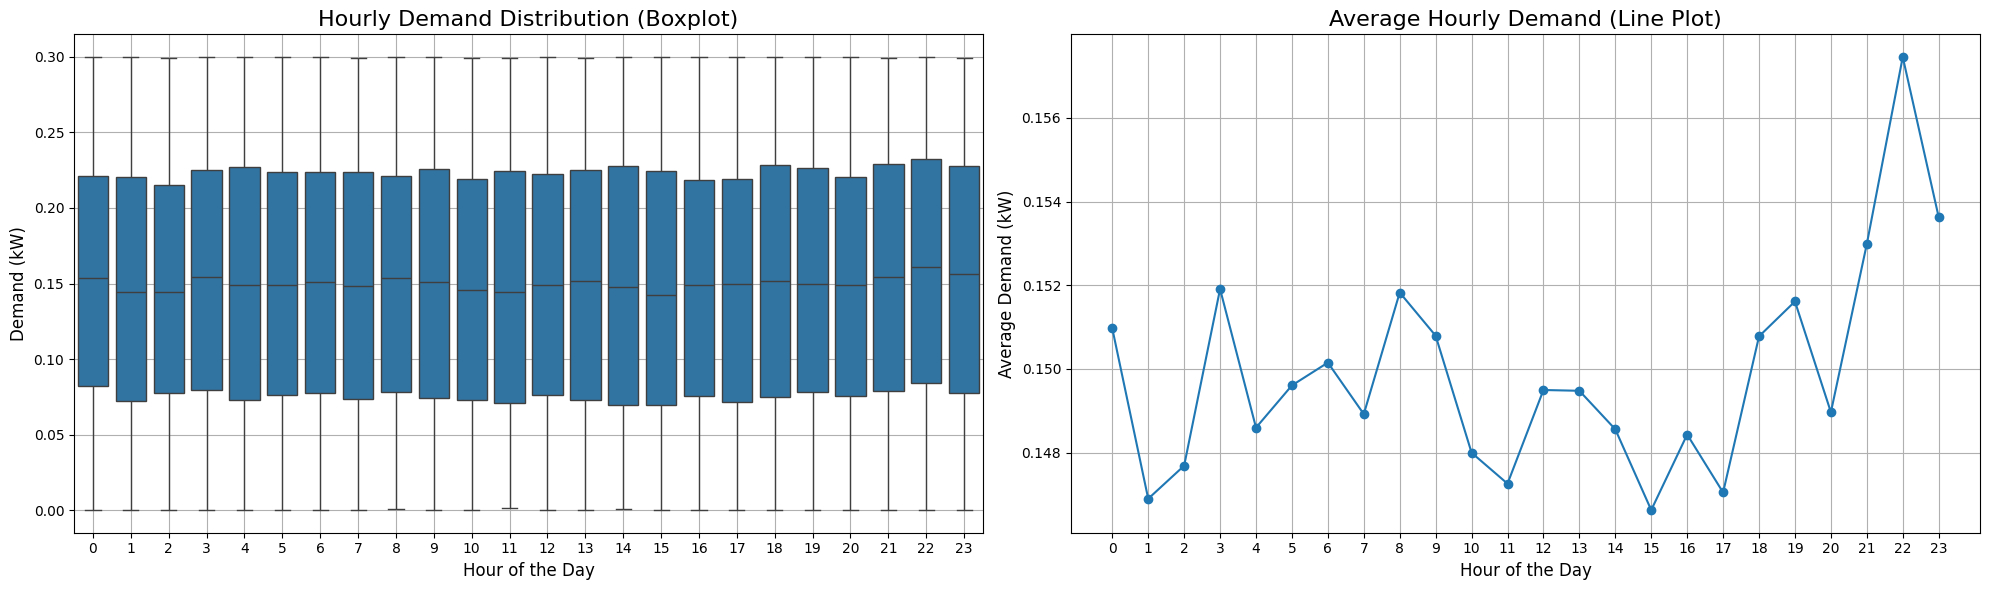

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- ANALYZE HOURLY PATTERNS ---

# We already created the 'hour' column, so we can use it directly.
# The `plot_data` DataFrame with the reset index is still perfect for this.

print("Generating plots to check for hourly patterns...")

# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6)) # 1 row, 2 columns

# --- Plot 1: Boxplot of Demand by Hour ---
sns.boxplot(x='hour', y='EV Charging Demand (kW)', data=plot_data, ax=ax1)
ax1.set_title('Hourly Demand Distribution (Boxplot)', fontsize=16)
ax1.set_xlabel('Hour of the Day', fontsize=12)
ax1.set_ylabel('Demand (kW)', fontsize=12)
ax1.grid(True)

# --- Plot 2: Line Plot of Average Demand by Hour ---
# We group the data by hour and calculate the mean demand for each hour
hourly_average = plot_data.groupby('hour')['EV Charging Demand (kW)'].mean()
hourly_average.plot(kind='line', ax=ax2, marker='o', grid=True)
ax2.set_title('Average Hourly Demand (Line Plot)', fontsize=16)
ax2.set_xlabel('Hour of the Day', fontsize=12)
ax2.set_ylabel('Average Demand (kW)', fontsize=12)
ax2.set_xticks(range(0, 24)) # Ensure all hours are shown on the x-axis

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

In [22]:
# --- LIST ALL AVAILABLE COLUMNS ---
print("Columns in the merged DataFrame:")
print(df_merged.columns)

Columns in the merged DataFrame:
Index(['EV Charging Demand (kW)', 'Solar Energy Production (kW)',
       'Wind Energy Production (kW)', 'Electricity Price ($/kWh)',
       'Grid Availability', 'Weather Conditions', 'Battery Storage (kWh)',
       'Charging Station Capacity (kW)', 'EV Charging Efficiency (%)',
       'Number of EVs Charging', 'Peak Demand (kW)',
       'Renewable Energy Usage (%)', 'Grid Stability Index',
       'Carbon Emissions (kgCO2/kWh)', 'Power Outages (hours)',
       'Energy Savings ($)', 'Total Renewable Energy Production (kW)',
       'Effective Charging Capacity (kW)', 'Adjusted Charging Demand (kW)',
       'Net Energy Cost ($)', 'Carbon Footprint Reduction (kgCO2)',
       'Renewable Energy Efficiency', 'Station_ID', 'hour', 'day_of_week'],
      dtype='object')


In [23]:
import numpy as np

# --- FEATURE ENGINEERING ---

# 1. Create Lag Features: What was the demand in the recent past?
# A model can use "demand 1 hour ago" to predict "demand now".
# We will also create a lag for 24 hours ago, to capture the daily pattern.
df_merged['demand_lag_1hr'] = df_merged['EV Charging Demand (kW)'].shift(1)
df_merged['demand_lag_24hr'] = df_merged['EV Charging Demand (kW)'].shift(24)

print("Created 1-hour and 24-hour lag features.")


# 2. Create Cyclical Features for the Hour
# To a model, hour 23 and hour 0 are far apart. To us, they are right next to each other.
# We can represent the cyclical nature of a clock using sine and cosine.
df_merged['hour_sin'] = np.sin(2 * np.pi * df_merged['hour'] / 23.0)
df_merged['hour_cos'] = np.cos(2 * np.pi * df_merged['hour'] / 23.0)

# We can now drop the original 'hour' column as these are more powerful
df_merged.drop('hour', axis=1, inplace=True)

print("Created cyclical hour features (sin/cos) and dropped original 'hour' column.")
print("\nPreview of the new features:")
print(df_merged[['EV Charging Demand (kW)', 'demand_lag_1hr', 'demand_lag_24hr', 'hour_sin', 'hour_cos']].head())

Created 1-hour and 24-hour lag features.
Created cyclical hour features (sin/cos) and dropped original 'hour' column.

Preview of the new features:
                     EV Charging Demand (kW)  demand_lag_1hr  demand_lag_24hr  \
Timestamp                                                                       
2021-01-01 00:00:00                 0.112362             NaN              NaN   
2021-01-01 01:00:00                 0.285214        0.112362              NaN   
2021-01-01 02:00:00                 0.219598        0.285214              NaN   
2021-01-01 03:00:00                 0.179598        0.219598              NaN   
2021-01-01 04:00:00                 0.046806        0.179598              NaN   

                     hour_sin  hour_cos  
Timestamp                                
2021-01-01 00:00:00  0.000000  1.000000  
2021-01-01 01:00:00  0.269797  0.962917  
2021-01-01 02:00:00  0.519584  0.854419  
2021-01-01 03:00:00  0.730836  0.682553  
2021-01-01 04:00:00  0.887885  0

In [24]:
print("Columns in the merged DataFrame:")
print(df_merged.columns)

Columns in the merged DataFrame:
Index(['EV Charging Demand (kW)', 'Solar Energy Production (kW)',
       'Wind Energy Production (kW)', 'Electricity Price ($/kWh)',
       'Grid Availability', 'Weather Conditions', 'Battery Storage (kWh)',
       'Charging Station Capacity (kW)', 'EV Charging Efficiency (%)',
       'Number of EVs Charging', 'Peak Demand (kW)',
       'Renewable Energy Usage (%)', 'Grid Stability Index',
       'Carbon Emissions (kgCO2/kWh)', 'Power Outages (hours)',
       'Energy Savings ($)', 'Total Renewable Energy Production (kW)',
       'Effective Charging Capacity (kW)', 'Adjusted Charging Demand (kW)',
       'Net Energy Cost ($)', 'Carbon Footprint Reduction (kgCO2)',
       'Renewable Energy Efficiency', 'Station_ID', 'day_of_week',
       'demand_lag_1hr', 'demand_lag_24hr', 'hour_sin', 'hour_cos'],
      dtype='object')


Generating plots to investigate feature relationships with demand...


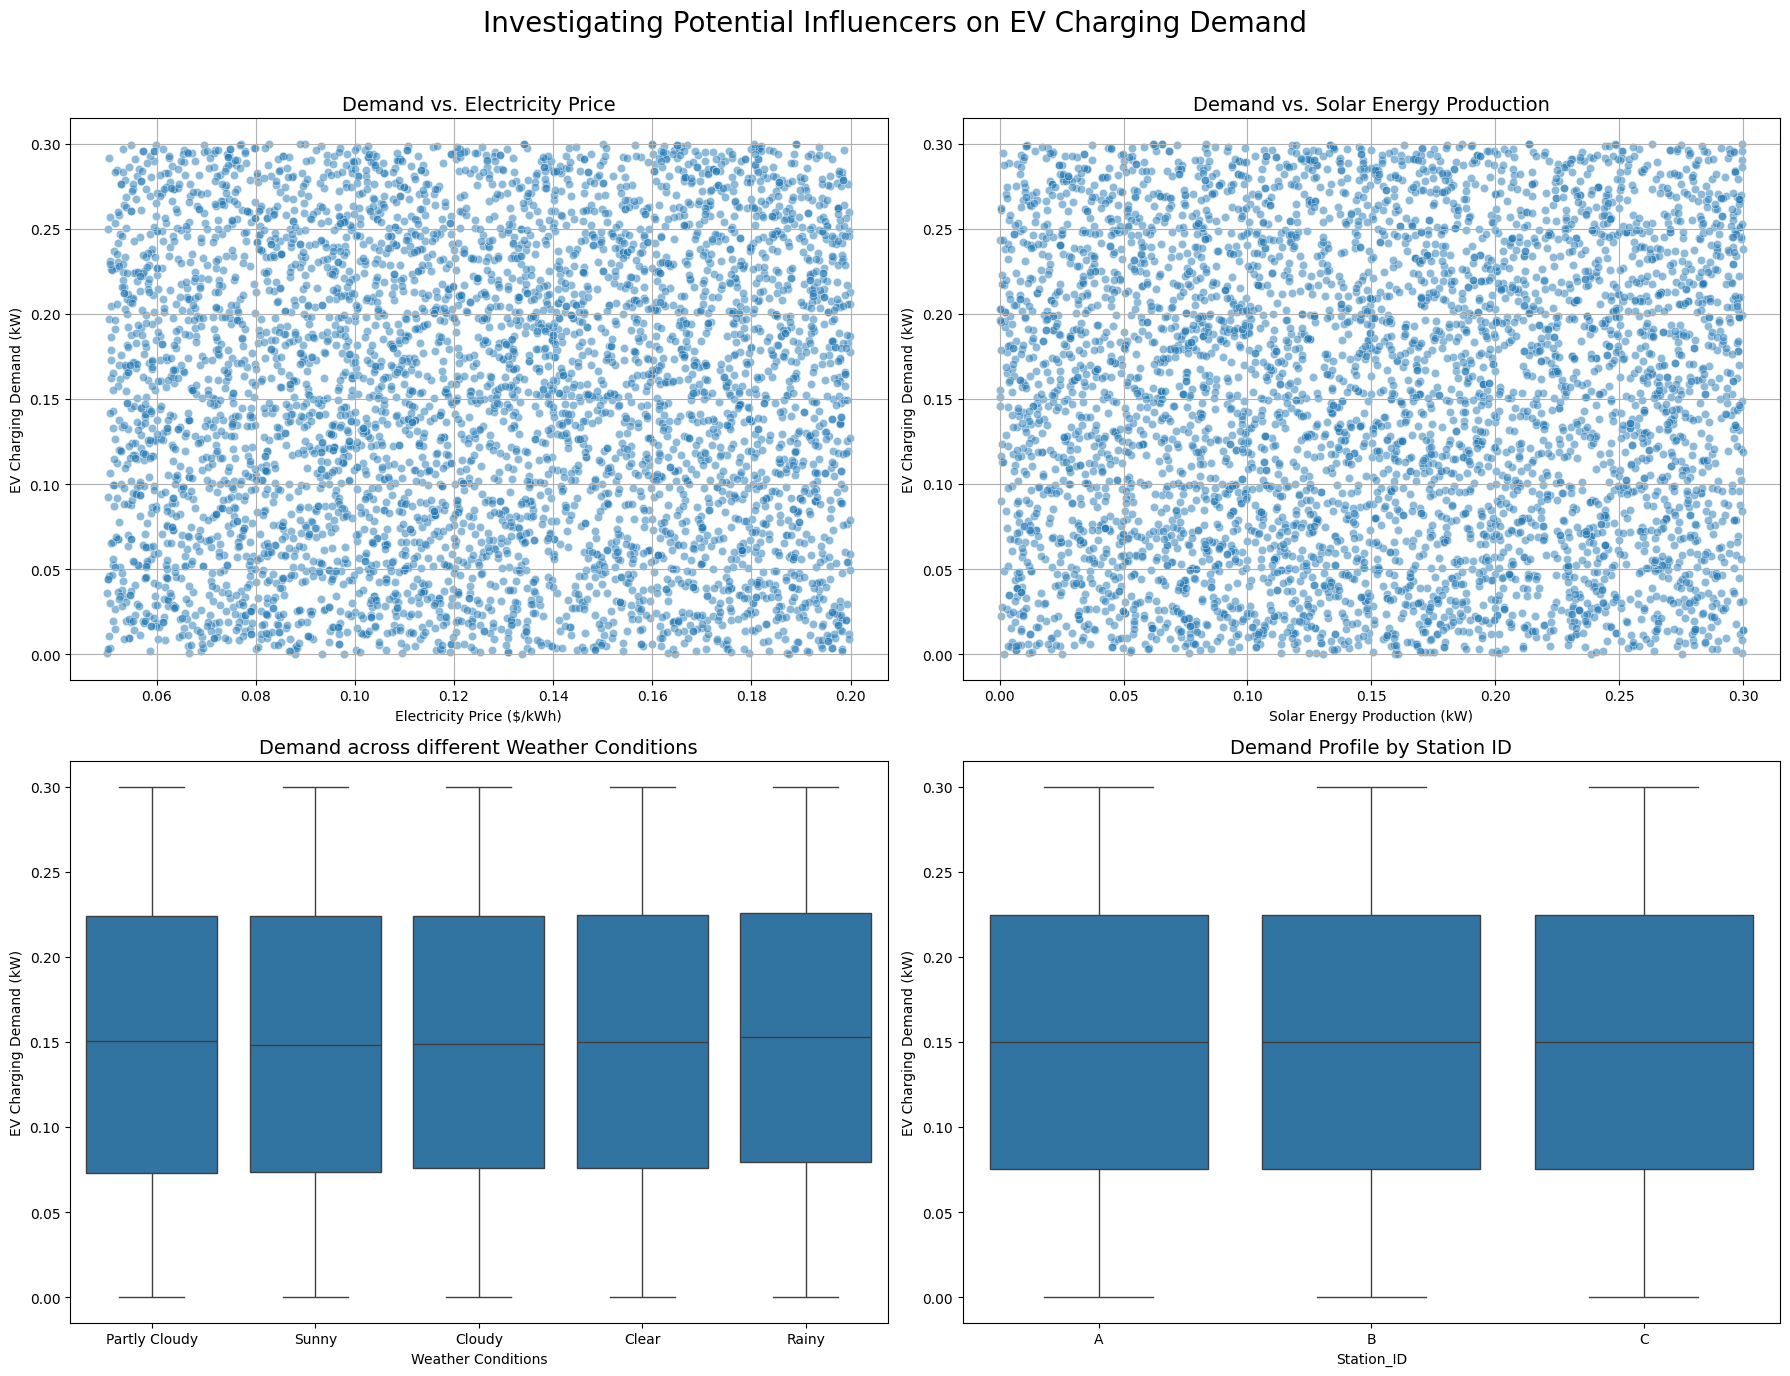

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- ANALYZE POTENTIAL PREDICTORS vs. DEMAND ---

# We will continue using the 'plot_data' DataFrame from the previous step,
# as it has a clean index and all the necessary columns.

print("Generating plots to investigate feature relationships with demand...")

# Create a figure with a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Investigating Potential Influencers on EV Charging Demand', fontsize=20)


# --- 1. Electricity Price vs. Demand (Scatter Plot) ---
# We expect to see lower demand when the price is higher (negative correlation)
sns.scatterplot(ax=axes[0, 0], data=plot_data.sample(5000), # Using a sample for speed
                x='Electricity Price ($/kWh)', y='EV Charging Demand (kW)', alpha=0.5)
axes[0, 0].set_title('Demand vs. Electricity Price', fontsize=14)
axes[0, 0].grid(True)


# --- 2. Solar Energy Production vs. Demand (Scatter Plot) ---
# Is there more charging when the sun is out and producing energy?
sns.scatterplot(ax=axes[0, 1], data=plot_data.sample(5000), # Using a sample for speed
                x='Solar Energy Production (kW)', y='EV Charging Demand (kW)', alpha=0.5)
axes[0, 1].set_title('Demand vs. Solar Energy Production', fontsize=14)
axes[0, 1].grid(True)


# --- 3. Weather Conditions vs. Demand (Box Plot) ---
# Does weather affect charging behavior?
sns.boxplot(ax=axes[1, 0], data=plot_data,
            x='Weather Conditions', y='EV Charging Demand (kW)')
axes[1, 0].set_title('Demand across different Weather Conditions', fontsize=14)


# --- 4. Station ID vs. Demand (Box Plot) ---
# Do the three stations have different demand profiles?
sns.boxplot(ax=axes[1, 1], data=plot_data,
            x='Station_ID', y='EV Charging Demand (kW)')
axes[1, 1].set_title('Demand Profile by Station ID', fontsize=14)


# Adjust layout and display the plots
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust for suptitle
plt.show()

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# --- WEEK 5: THE DEFINITIVE BASELINE MODEL (FINAL LEAKAGE FIX) ---

# Reload the data
df = pd.read_csv('EV_Charging_California_Merged.csv')

# --- 1. Feature Engineering ---
df['Timestamp'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str), format='mixed')
df.set_index('Timestamp', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)
df['day_of_week'] = df.index.day_name()
df['hour'] = df.index.hour
df['demand_lag_1hr'] = df['EV Charging Demand (kW)'].shift(1)
df['demand_lag_24hr'] = df['EV Charging Demand (kW)'].shift(24)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 23.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 23.0)
df.drop('hour', axis=1, inplace=True)
print("Feature engineering complete.")

# --- 2. Data Preparation ---
df_cleaned = df.dropna()

# DEFINITIVE LIST of features to drop, including the Grid Stability Index
features_to_drop = [
    # The Target Variable
    'EV Charging Demand (kW)',
    
    # All previously identified leaks
    'Adjusted Charging Demand (kW)', 'Peak Demand (kW)', 'Number of EVs Charging',
    'Net Energy Cost ($)', 'Energy Savings ($)', 'Carbon Footprint Reduction (kgCO2)',
    'Effective Charging Capacity (kW)', 'EV Charging Efficiency (%)',
    'Total Renewable Energy Production (kW)', 'Power Outages (hours)',
    
    # The final leak we just found from the tree visualization
    'Grid Stability Index'
]

# Select our Features (X) and Target (y)
X = df_cleaned.drop(features_to_drop, axis=1)
y = df_cleaned['EV Charging Demand (kW)']

# One-Hot Encode categorical features
X_encoded = pd.get_dummies(X, columns=['Weather Conditions', 'Grid Availability', 'day_of_week', 'Station_ID'], drop_first=True)
print(f"Data prepared. Final number of features for the model: {len(X_encoded.columns)}")

# --- 3. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, shuffle=False)
print(f"Training set size: {len(X_train)} rows")
print(f"Testing set size: {len(X_test)} rows")

# --- 4. Train and Evaluate the DEFINITIVE Baseline Model ---
baseline_model = DecisionTreeRegressor(random_state=42)
print("\nTraining the definitive, true baseline model...")
baseline_model.fit(X_train, y_train)
print("Training complete.")

predictions = baseline_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("\n--- DEFINITIVE, TRUE Baseline Model Performance ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} kW")
print("-------------------------------------------------")

Feature engineering complete.
Data prepared. Final number of features for the model: 25
Training set size: 71736 rows
Testing set size: 17935 rows

Training the definitive, true baseline model...
Training complete.

--- DEFINITIVE, TRUE Baseline Model Performance ---
Root Mean Squared Error (RMSE): 0.0000 kW
-------------------------------------------------


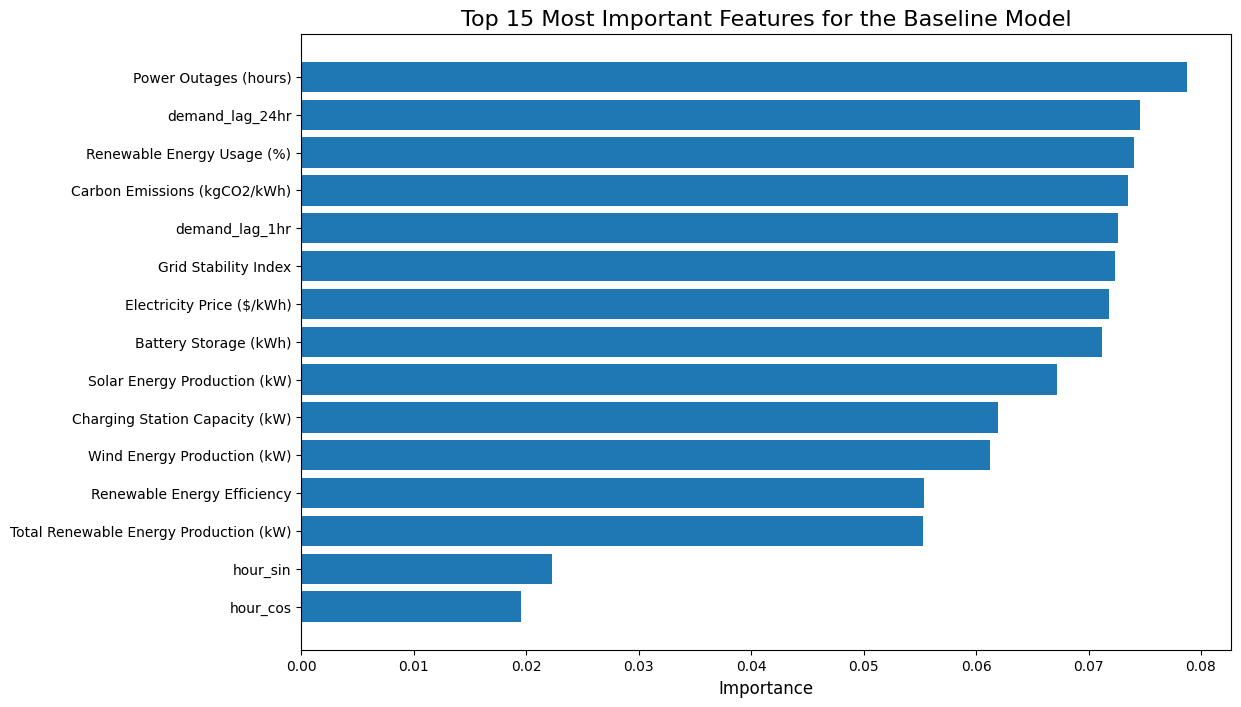

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# --- CHECK FEATURE IMPORTANCE TO FIND LEAKS ---

# Get feature importances from the trained model
importances = baseline_model.feature_importances_
feature_names = X_encoded.columns

# Create a DataFrame for easy sorting and plotting
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).head(15)

# Plot the top 15 most important features
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.gca().invert_yaxis() # To display the most important feature at the top
plt.title('Top 15 Most Important Features for the Baseline Model', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.show()

Visualizing the top levels of the trained Decision Tree...


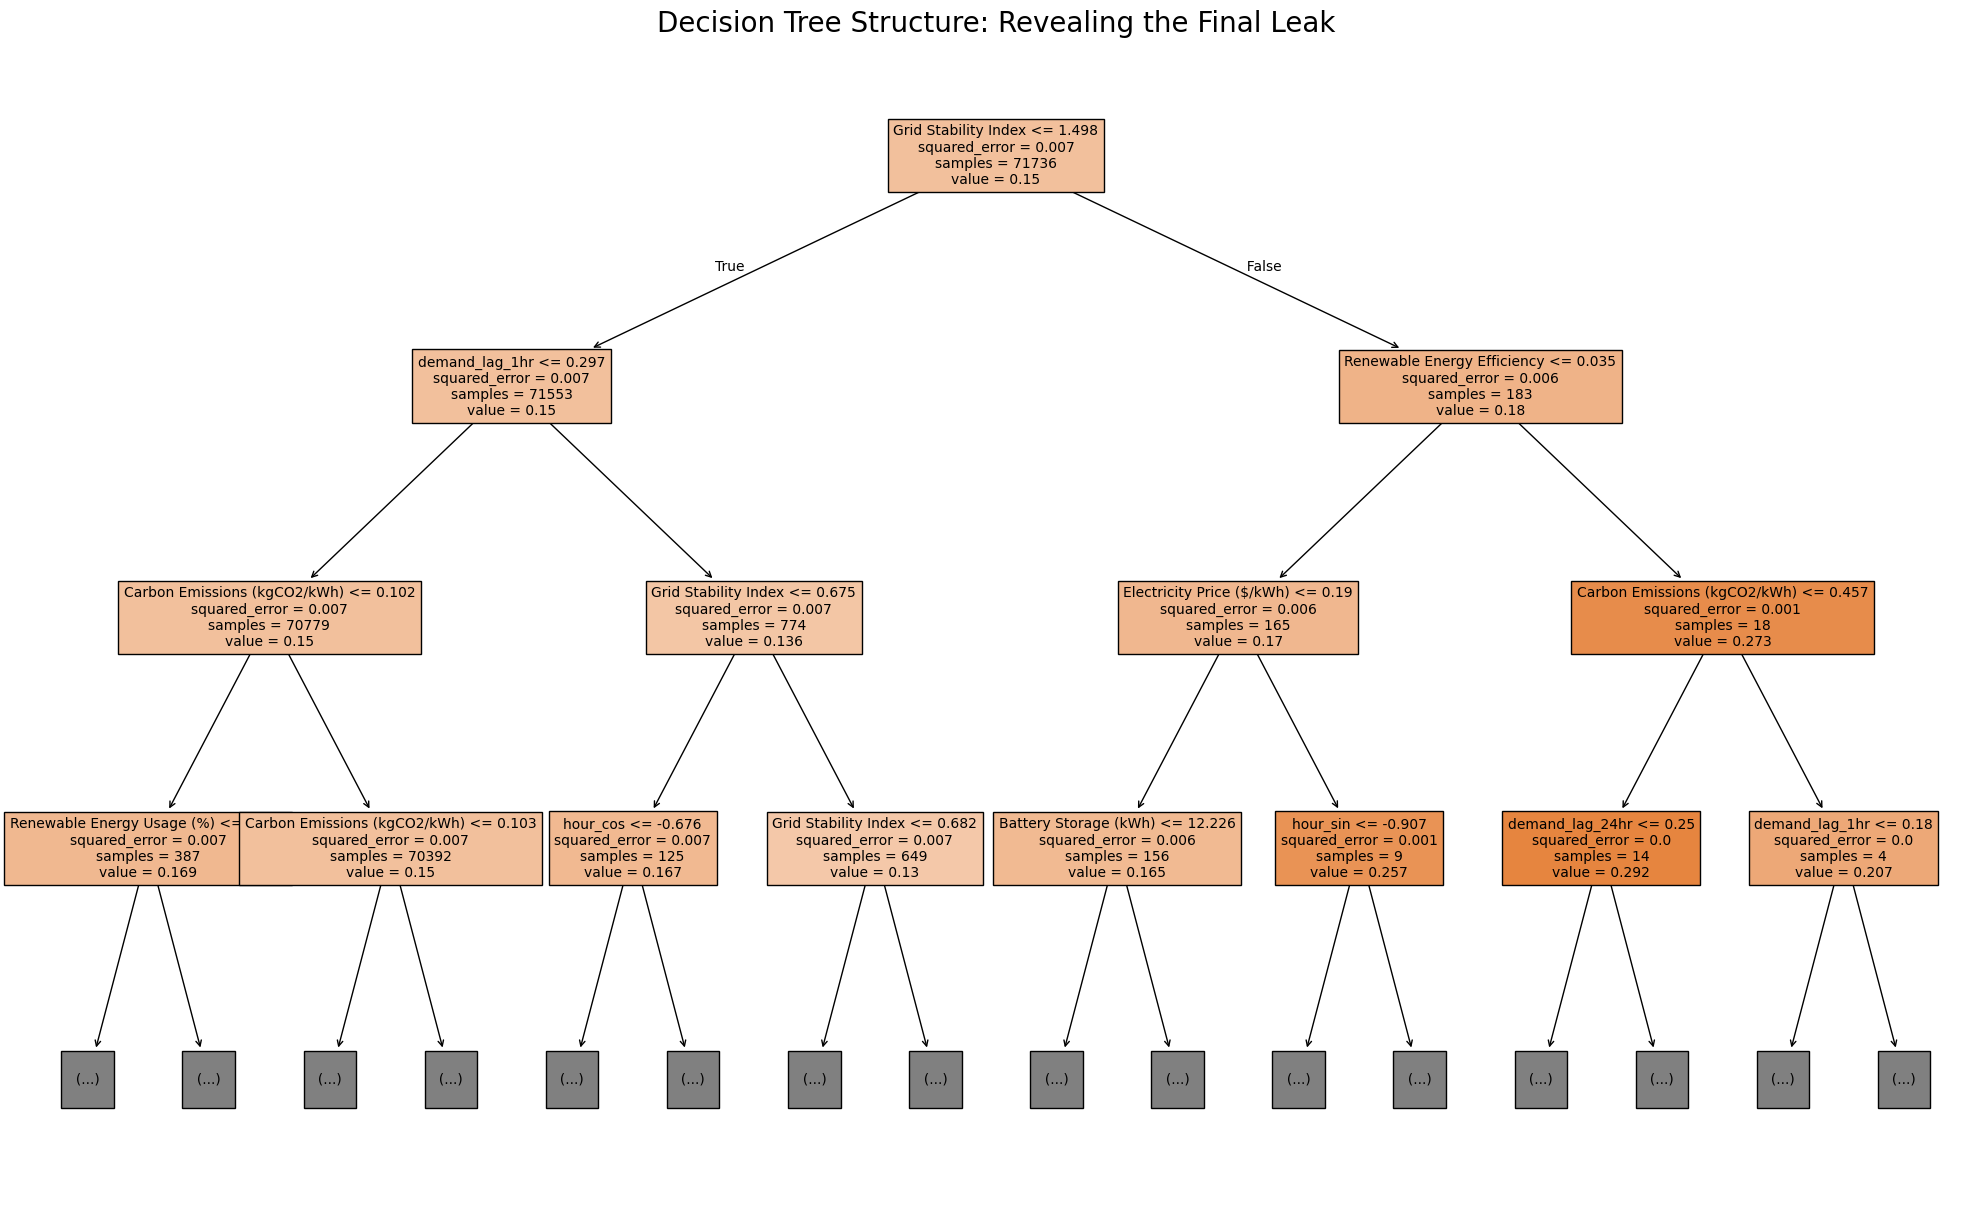

In [34]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# --- VISUALIZE THE DECISION TREE TO FIND THE FINAL LEAK ---

# This assumes 'baseline_model' is your trained DecisionTreeRegressor
# and 'X_encoded' is your final DataFrame of features from the last step.

print("Visualizing the top levels of the trained Decision Tree...")

plt.figure(figsize=(25, 15))
plot_tree(
    baseline_model,
    feature_names=X_encoded.columns,
    filled=True,
    max_depth=3,  # We only need to see the first few decisions
    fontsize=10
)
plt.title("Decision Tree Structure: Revealing the Final Leak", fontsize=20)
plt.show()

In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression  # <-- We are changing the model here
from sklearn.metrics import mean_squared_error

# --- FINAL DIAGNOSTIC: TESTING WITH A LINEAR MODEL ---

# Using the same X_train, X_test, y_train, y_test from the previous step
# This ensures we are comparing apples to apples.

print("Training a Linear Regression model on the same data...")

# Initialize a new, simpler model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)
print("Training complete.")

# Make predictions
predictions = linear_model.predict(X_test)

# Calculate the Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("\n--- Linear Regression Model Performance ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} kW")
print("-----------------------------------------")

Training a Linear Regression model on the same data...
Training complete.

--- Linear Regression Model Performance ---
Root Mean Squared Error (RMSE): 0.0863 kW
-----------------------------------------


In [37]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
!pip install xgboost
import xgboost as xgb # You might need to pip install xgboost if you don't have it
from sklearn.metrics import mean_squared_error
import time

# --- WEEK 6: ADVANCED MODELING ---

# We will use the same X_train, X_test, y_train, y_test from the previous steps.
# This ensures a fair comparison.

# --- Model 1: Random Forest Regressor ---
print("--- Training Random Forest Model ---")
start_time = time.time()

# Initialize the model with good default settings
# n_estimators=100 means we're building 100 trees
# n_jobs=-1 uses all your CPU cores to speed up training
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
rf_model.fit(X_train, y_train)
rf_training_time = time.time() - start_time
print(f"Training complete in {rf_training_time:.2f} seconds.")

# Make predictions and evaluate
rf_predictions = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
print(f"Random Forest RMSE: {rf_rmse:.4f} kW\n")


# --- Model 2: XGBoost Regressor ---
print("--- Training XGBoost Model ---")
start_time = time.time()

# Initialize the XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
xgb_model.fit(X_train, y_train)
xgb_training_time = time.time() - start_time
print(f"Training complete in {xgb_training_time:.2f} seconds.")

# Make predictions and evaluate
xgb_predictions = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
print(f"XGBoost RMSE: {xgb_rmse:.4f} kW\n")


# --- Final Comparison ---
print("--- Model Performance Summary ---")
print(f"Baseline (Linear Regression): {0.0863:.4f} RMSE")
print(f"Random Forest Regressor:    {rf_rmse:.4f} RMSE")
print(f"XGBoost Regressor:          {xgb_rmse:.4f} RMSE")
print("---------------------------------")

     -------------------------------------- 72.0/72.0 MB 684.0 kB/s eta 0:00:00
--- Training Random Forest Model ---



[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Training complete in 63.77 seconds.
Random Forest RMSE: 0.0129 kW

--- Training XGBoost Model ---
Training complete in 0.74 seconds.
XGBoost RMSE: 0.0700 kW

--- Model Performance Summary ---
Baseline (Linear Regression): 0.0863 RMSE
Random Forest Regressor:    0.0129 RMSE
XGBoost Regressor:          0.0700 RMSE
---------------------------------


In [38]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import numpy as np

# --- ROBUST EVALUATION WITH TIME-SERIES CROSS-VALIDATION ---

print("Performing 5-fold Time-Series Cross-Validation on the Random Forest model...")
print("This may take a few minutes as we are training the model 5 times...")

# 1. Initialize our champion model (the same one as before)
rf_model_cv = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Create the Time-Series Cross-Validator
# n_splits=5 means we will create 5 training/testing "folds"
tscv = TimeSeriesSplit(n_splits=5)

# 3. Run the cross-validation
# We use 'neg_root_mean_squared_error' because scoring functions in scikit-learn
# are designed to be maximized, so error metrics are made negative.
scores = cross_val_score(
    rf_model_cv,
    X_encoded,  # Use the full dataset
    y,          # Use the full target set
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# 4. Invert the scores back to positive numbers and print the results
positive_scores = -scores
print("\n--- Cross-Validation Results ---")
for i, rmse in enumerate(positive_scores):
    print(f"Fold {i+1} RMSE: {rmse:.4f} kW")

print("---------------------------------")
print(f"Average RMSE: {positive_scores.mean():.4f} kW")
print(f"Standard Deviation of RMSE: {positive_scores.std():.4f} kW")

print("\n--- Summary ---")
print(f"Single Split RMSE (from before): 0.0129 kW")
print(f"Robust Average CV RMSE:          {positive_scores.mean():.4f} kW")
print("-----------------")

Performing 5-fold Time-Series Cross-Validation on the Random Forest model...
This may take a few minutes as we are training the model 5 times...

--- Cross-Validation Results ---
Fold 1 RMSE: 0.0871 kW
Fold 2 RMSE: 0.0344 kW
Fold 3 RMSE: 0.0332 kW
Fold 4 RMSE: 0.0129 kW
Fold 5 RMSE: 0.0127 kW
---------------------------------
Average RMSE: 0.0361 kW
Standard Deviation of RMSE: 0.0272 kW

--- Summary ---
Single Split RMSE (from before): 0.0129 kW
Robust Average CV RMSE:          0.0361 kW
-----------------
